# Modeling Power Outages by County in Maine

The goal of this notebook is to use sktime to predict customers.out in the counties in Maine.

Maine has only sixteen counties with a wide range of topography and population. 
If we are able to set up hierarchical methods for ME, we should be able to scale up to the entire US.

The outline of the notebook is:
- Setup
    - Import packages
    - Load and arrange the data
- EDA
    - Graph customers.out as time series for each county
    - Make ACF graphs for each county to identify potential seasonality
    - Check for stationarity
    - Make PACF graphs to suggest model order
- Univeriate analysis: ARIMA
    - Set up ARIMA to do a forecast for one year... just to show we can do it
    - Set up ARIMA using a sliding window... just to show we can do it
    - Do cross-validation with a sliding window
- Incorporating exogenous variables: VARIMAX
    - Something...

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sktime.utils.plotting import plot_series
from sktime.forecasting.arima import ARIMA
from sktime.split import temporal_train_test_split
from sktime.forecasting.base import ForecastingHorizon

## Load and Arrange the Data

We'll load the dataset with eaglei, noaa, era5, county-level, and engineered variables

We'll restrict to our training set (pre-2022)

For now, we'll also restrict ourselves to Maine, which has just 16 counties--a sufficient number to let us try out the techniques before deploying on the entire country

In [3]:
#Load the engineered data
df = pd.read_parquet('../Data/Merged_Data/eaglei_noaa_era5_engineered.parquet')

In [4]:
# Restrict df to years prior to 2022
# For now, we'll just focus on Maine
df = df[df['STUSPS'] == 'ME']
df = df[df['YEAR'] < 2022]

# Use fips_code and datetime as indices
df = df.set_index(['fips_code', 'datetime'])

#Sort df
df = df.sort_index()

### Set the y-variable

We'll need to do a bit of work with the index to make it compatible with sktime.
Specifically, we'll need to recreate the multiindex and imbue it with a frequency

In [5]:
y = df['customers_out']

#Set the multiindex on y
y = y.reset_index()

#Use fips_code and datetime as a multiindex on y
y = y.set_index(['fips_code', 'datetime'])

# Note that datetime doesn't have an embedded frequency; we'll need to set this manually
#Convert DatetimeIndex to PeriodIndex with 6-hour frequency
y.index = y.index.set_levels(y.index.levels[1].to_period('6h'), level=1)

## Graphing the Data

We'll start by making some plots of the data to get a sense of the sparsity of the data

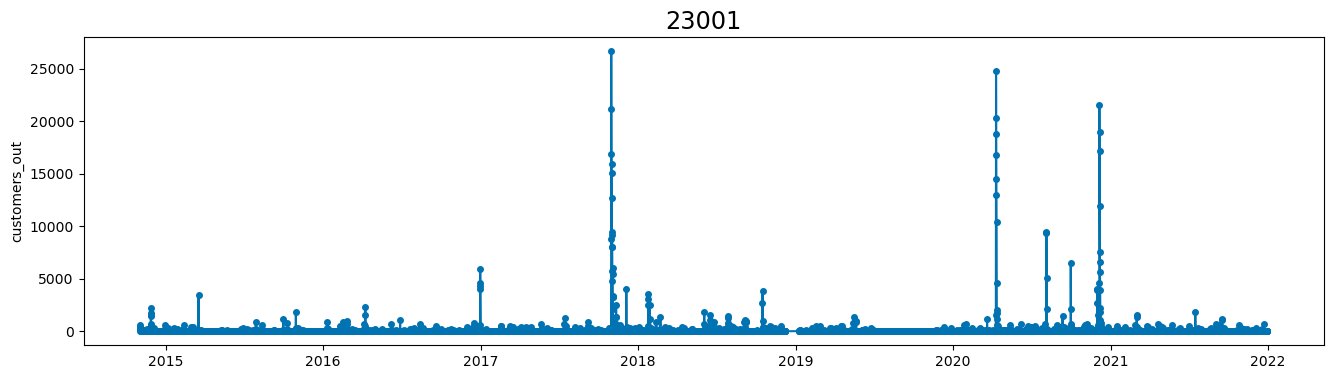

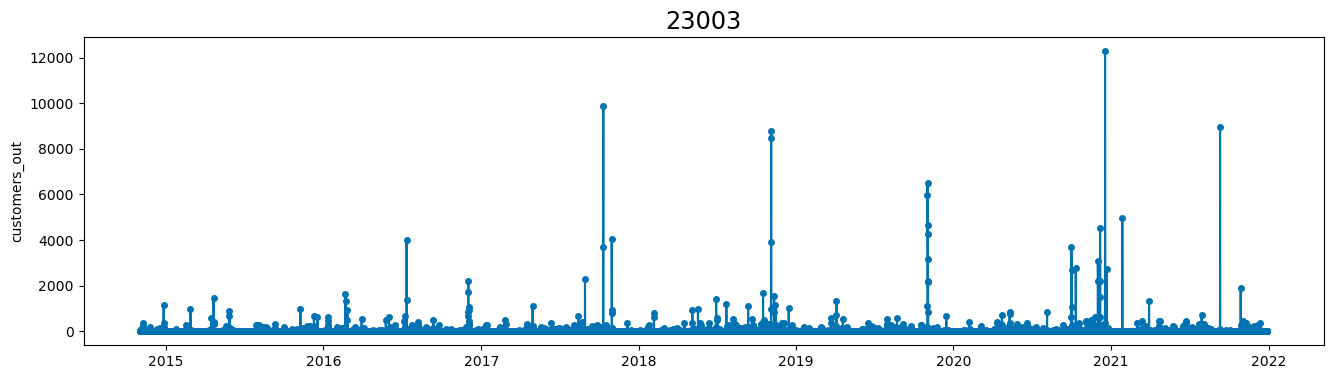

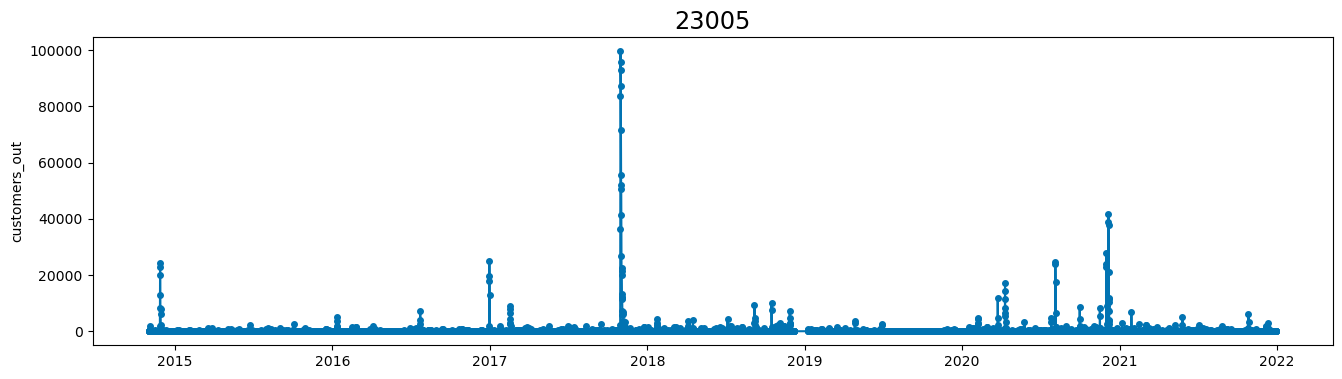

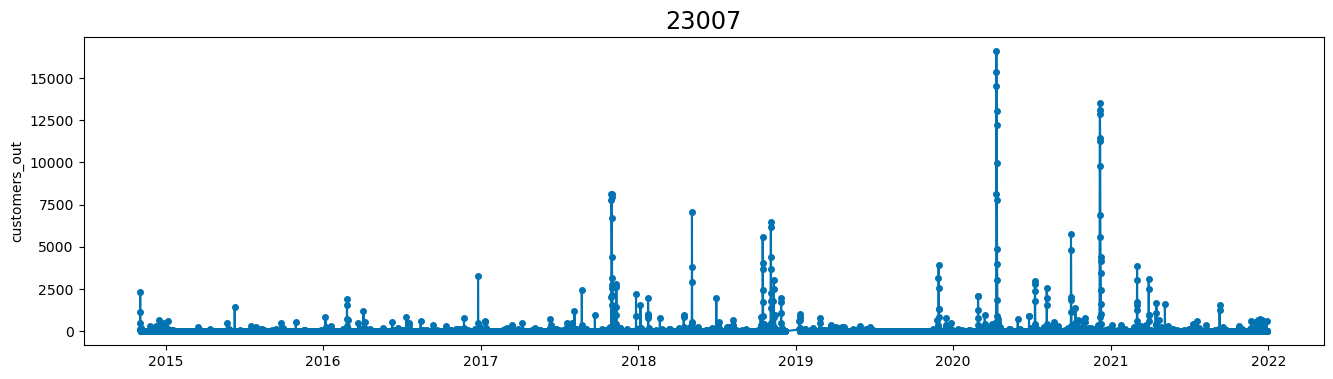

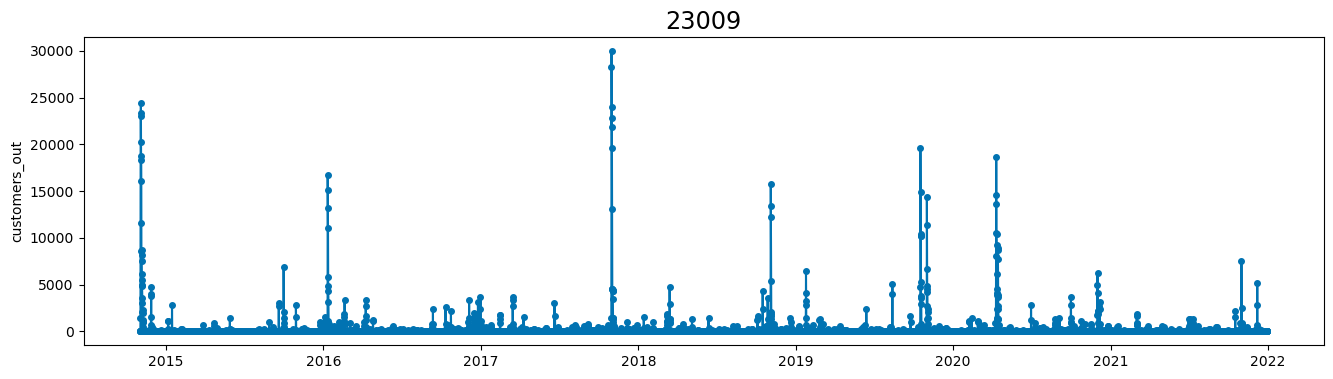

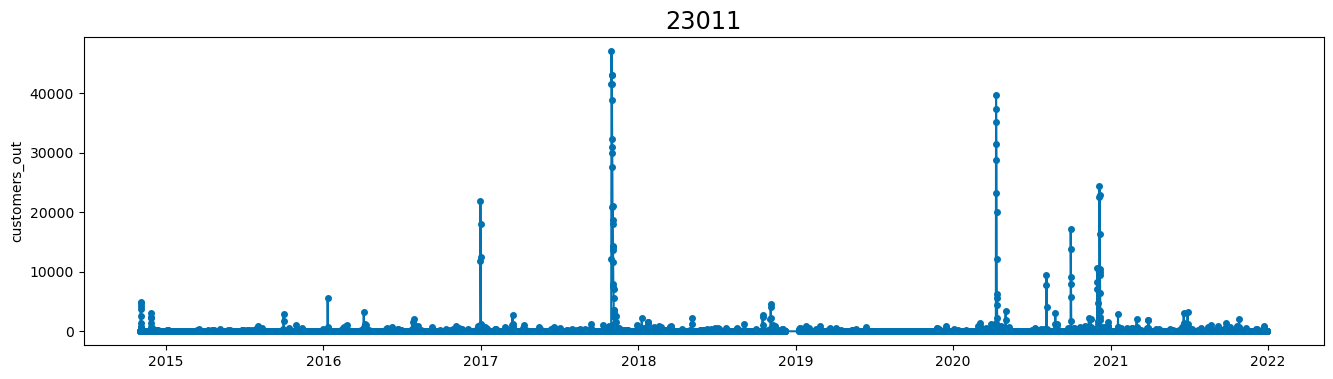

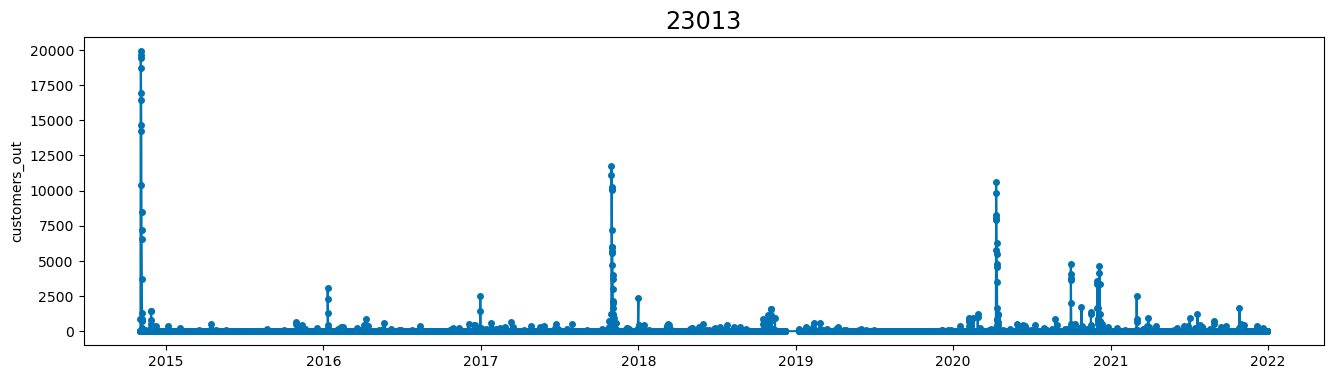

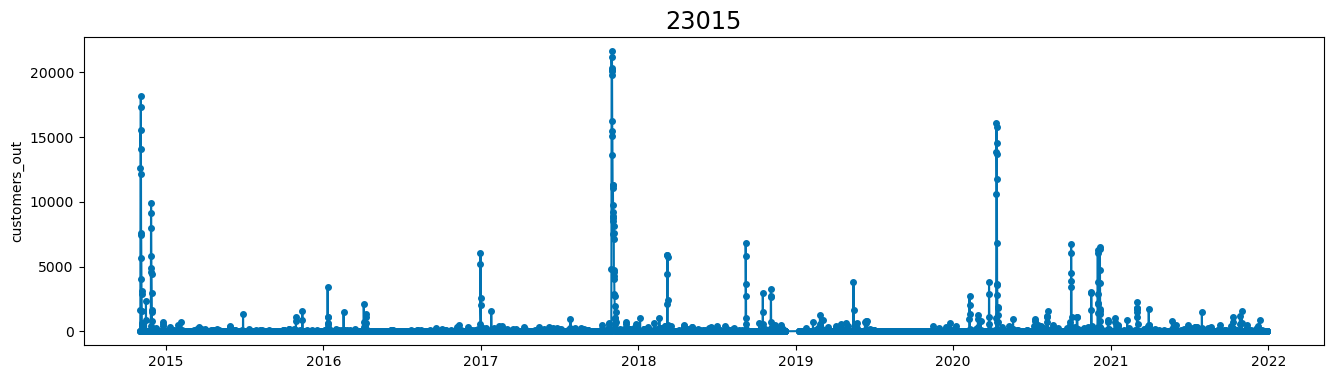

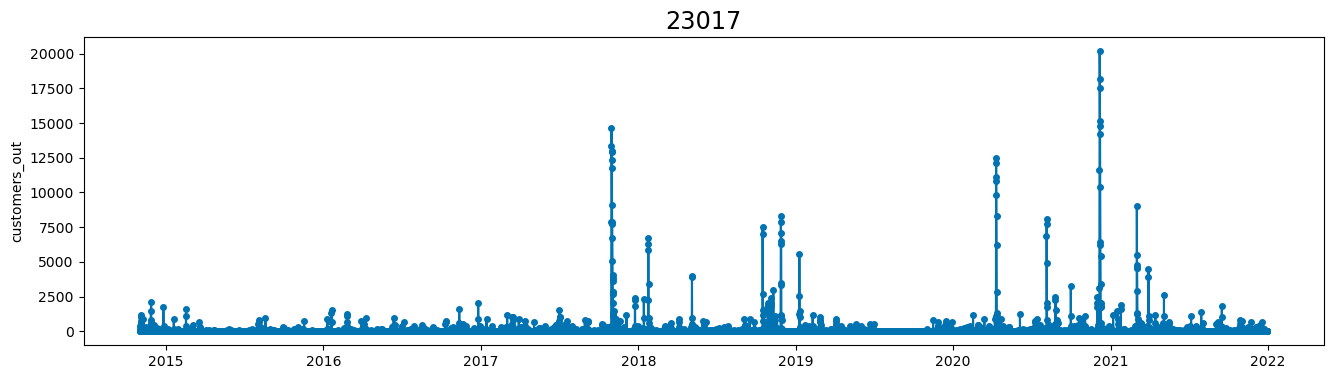

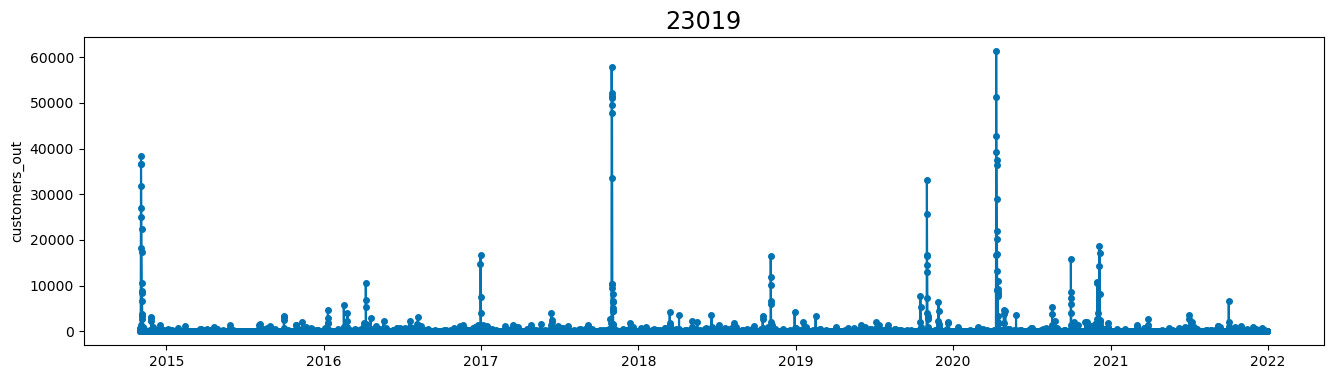

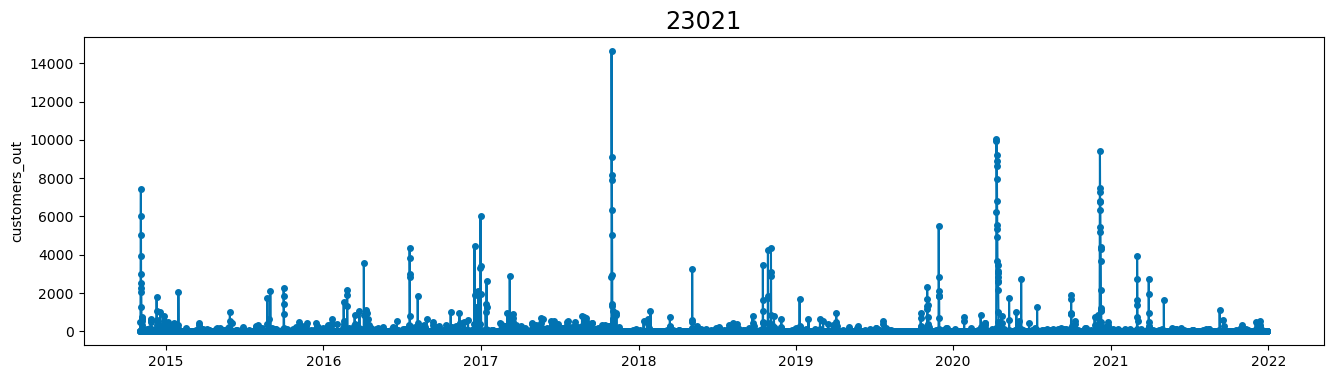

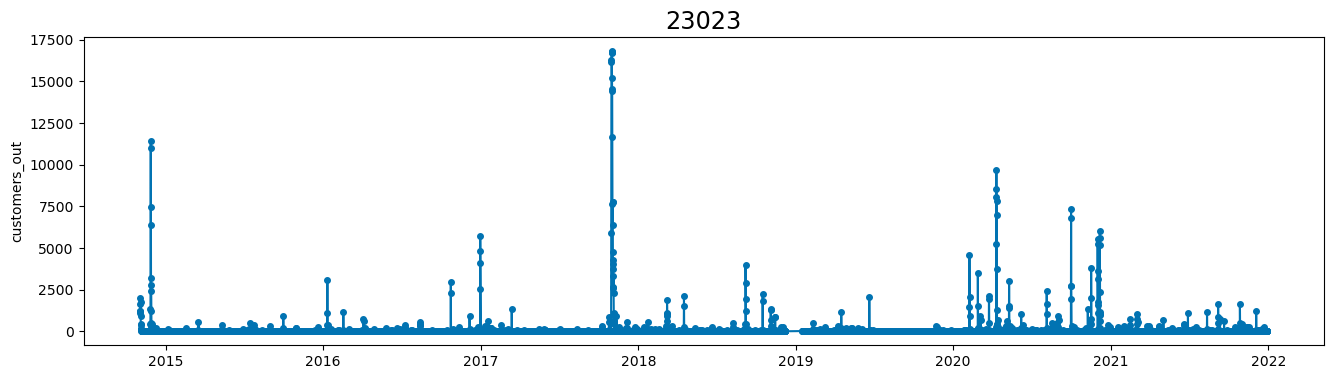

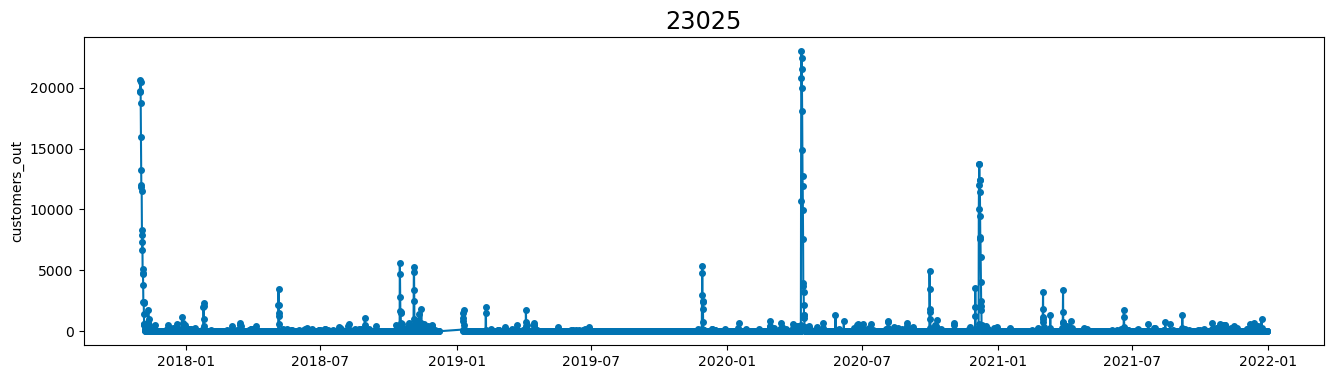

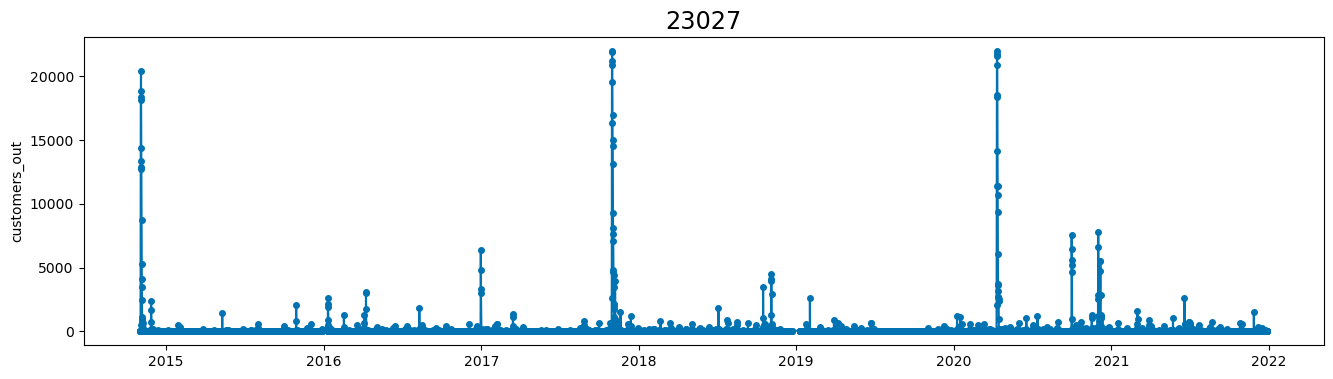

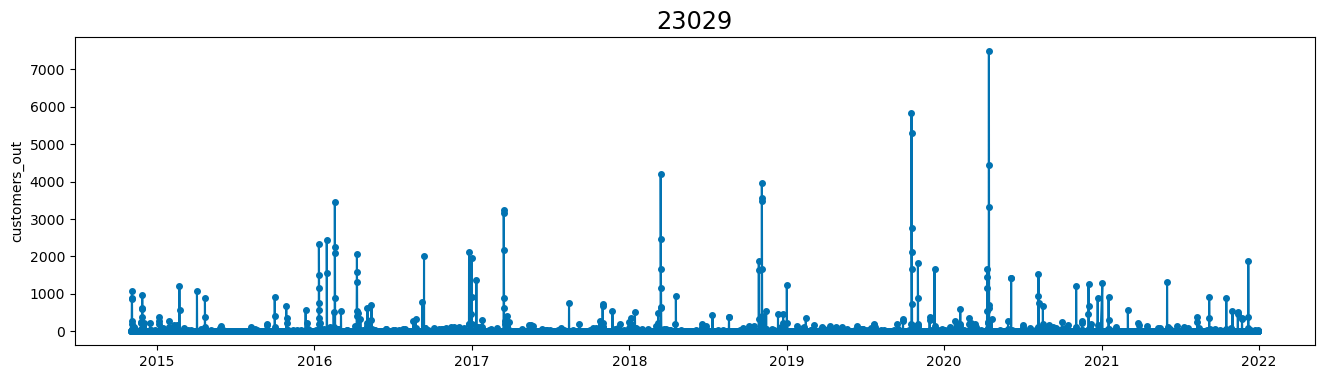

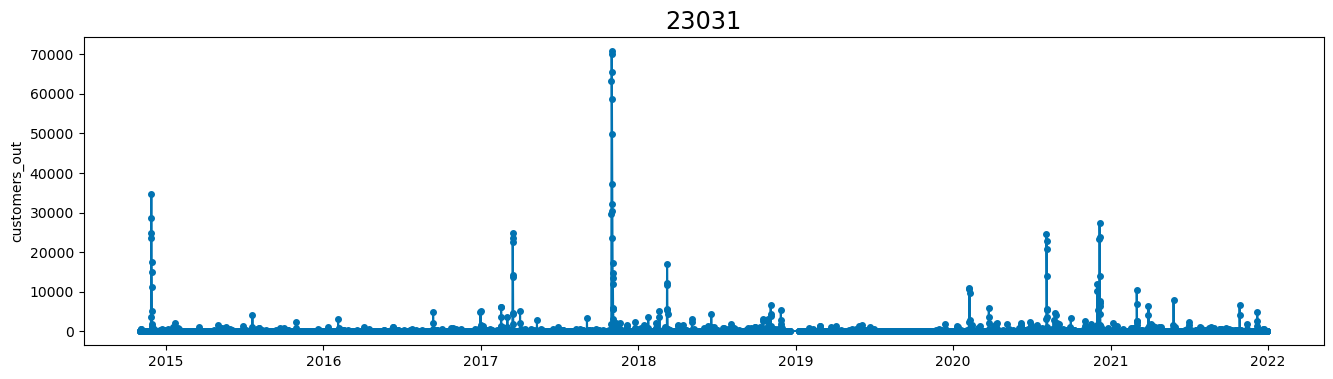

In [39]:
#For each value of fips_code, plot the value of y
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    #sort y_fips
    y_fips = y_fips.sort_index()
    plot_series(y_fips, title=fips_code)

## ACF and PACF plots

We'll make an autocorrelation and partial autocorrelation plot for each of the counties.

The ACF plots suggest that there are correlations with up to 15-20 lags, which corresponds to 4-5 days. There doesn't appear to be any consistent seasonality.

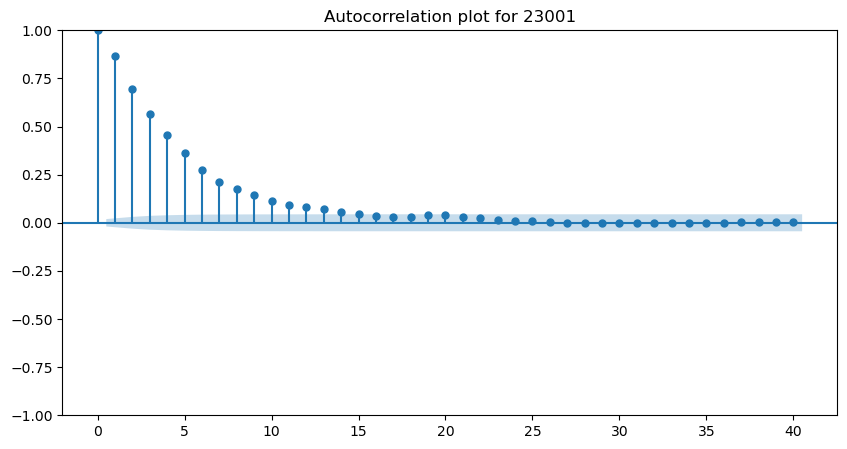

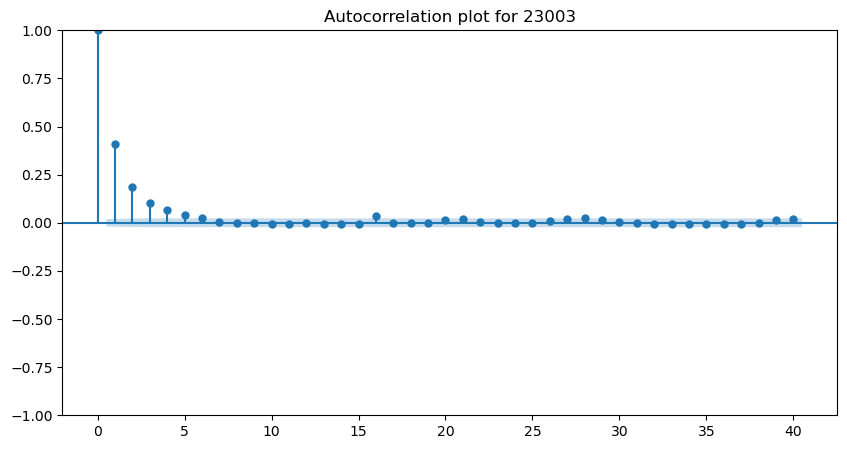

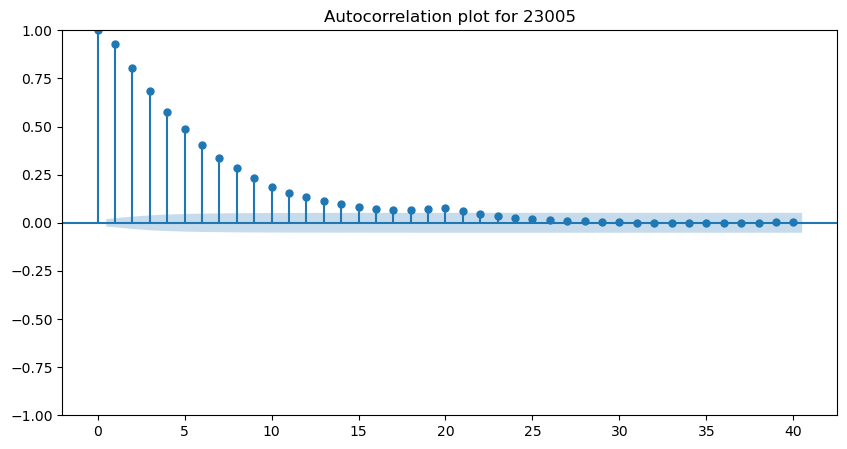

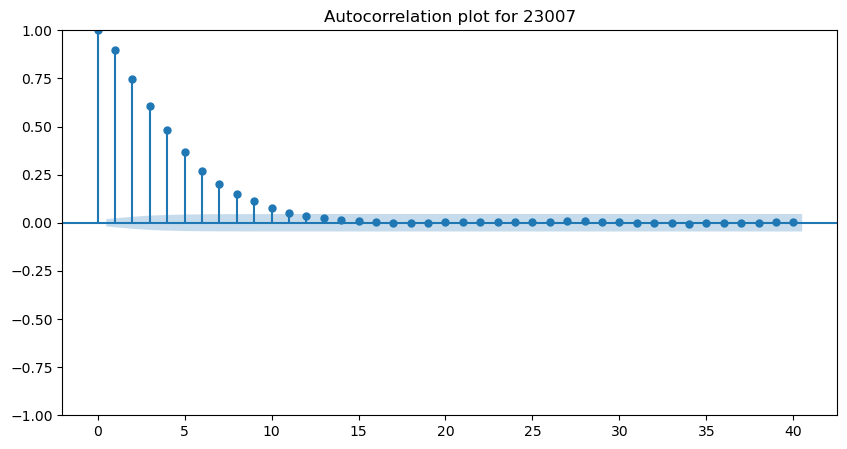

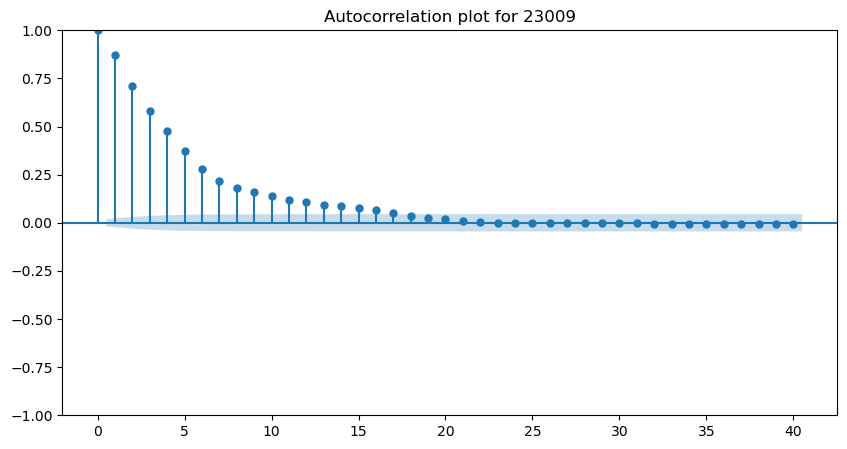

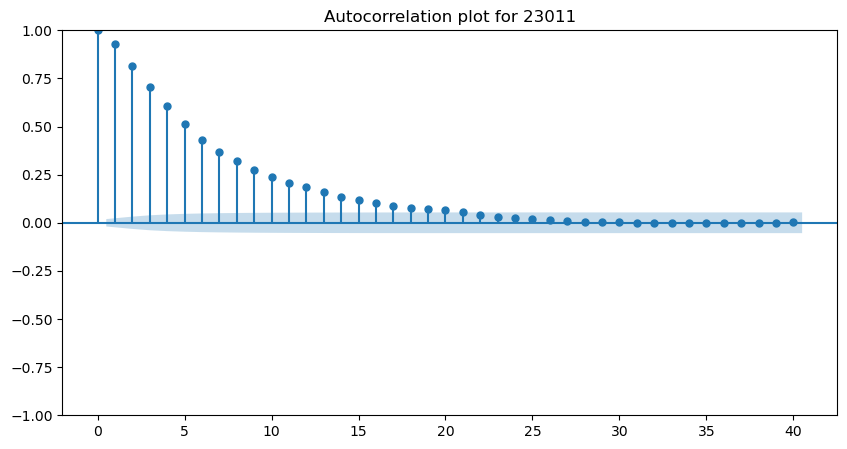

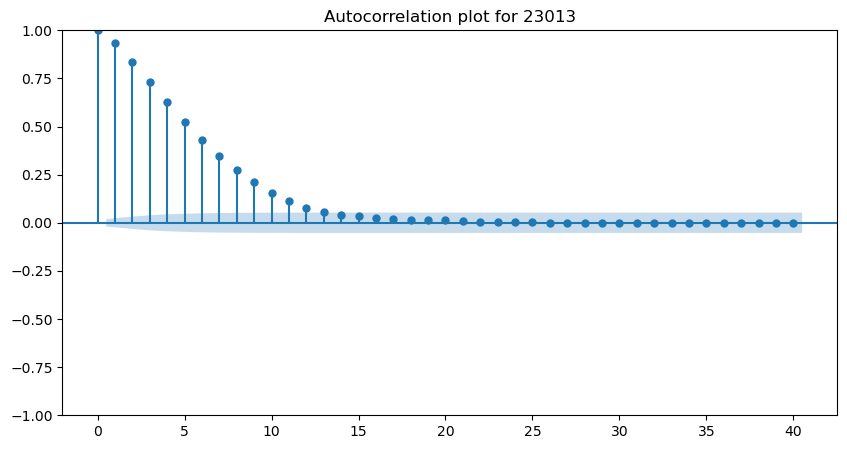

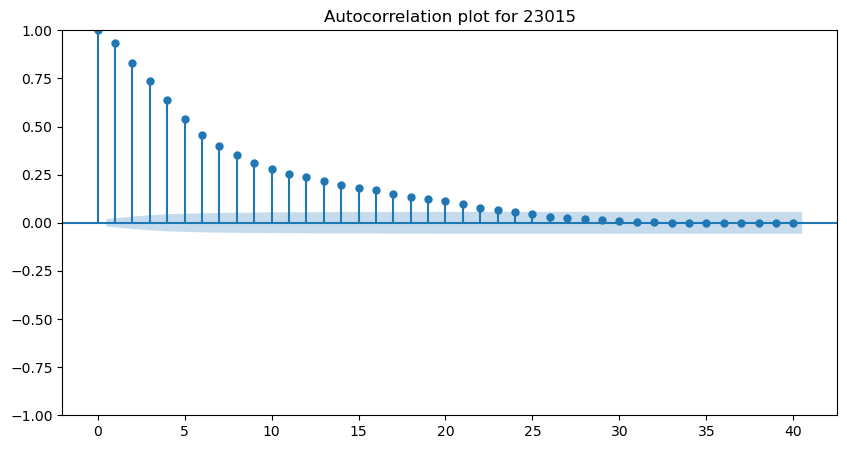

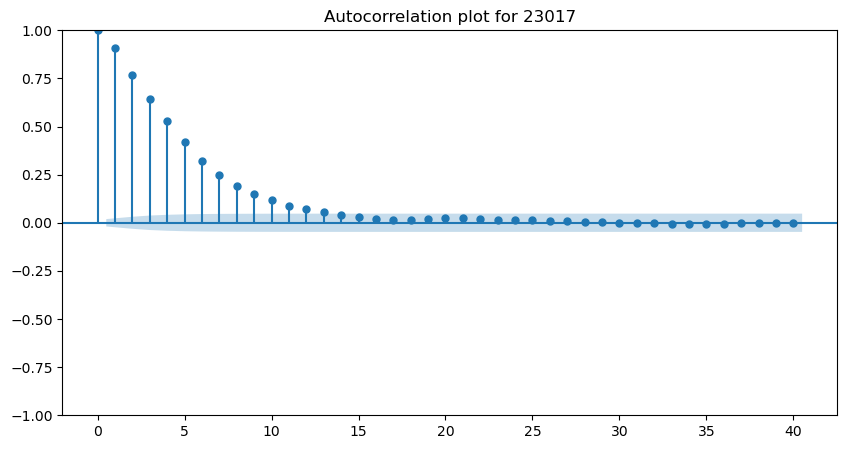

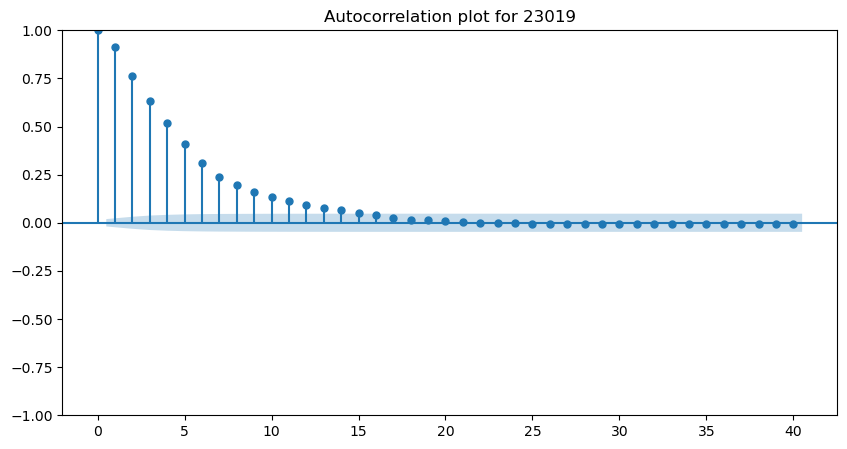

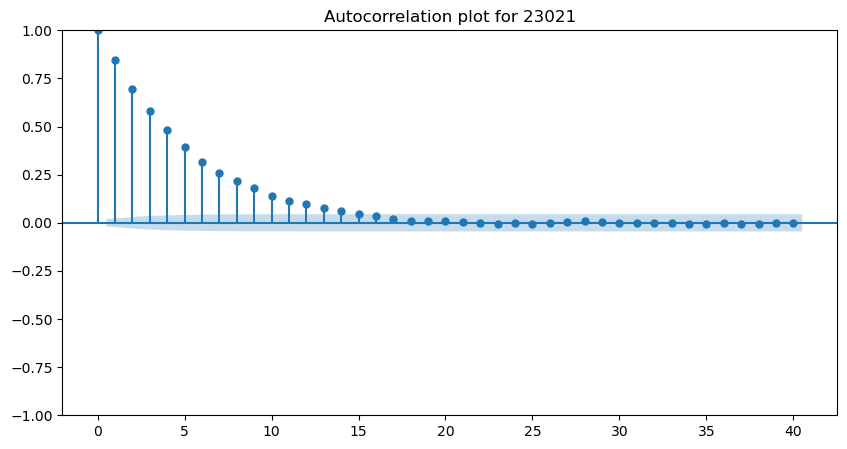

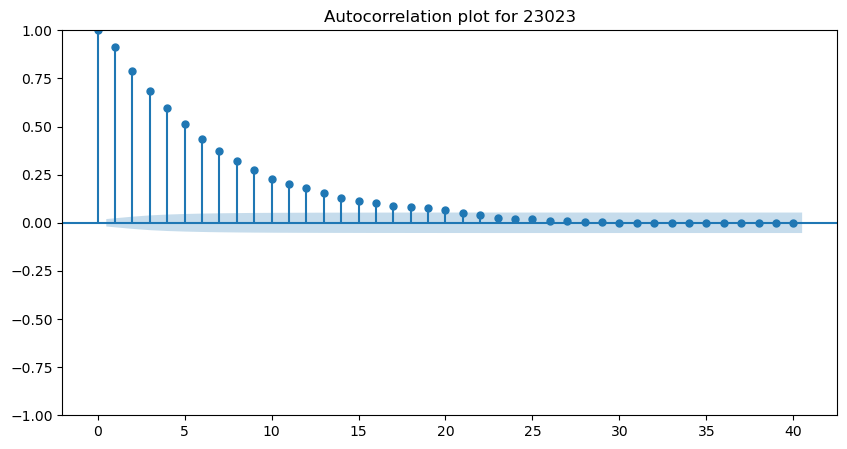

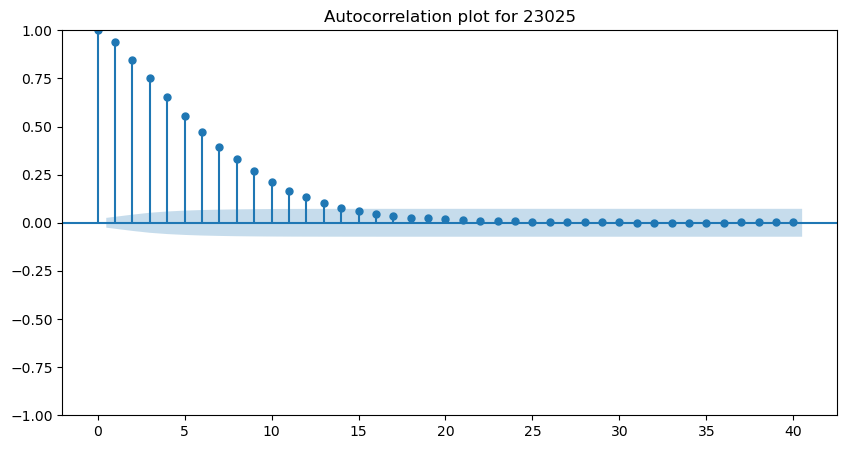

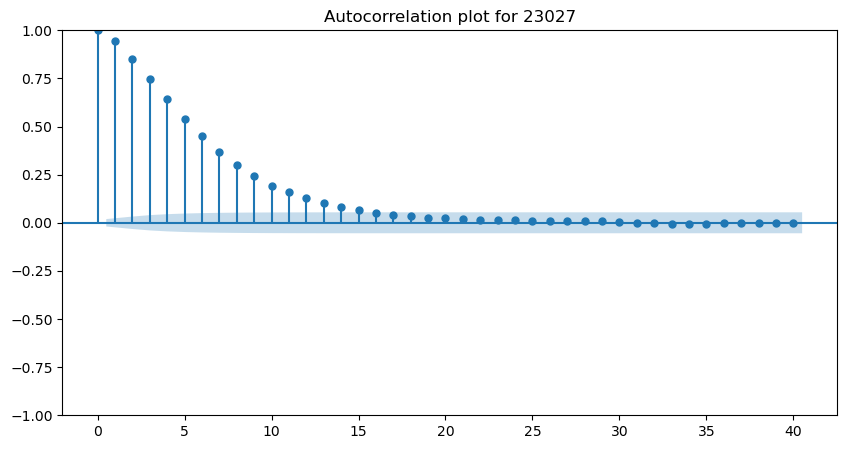

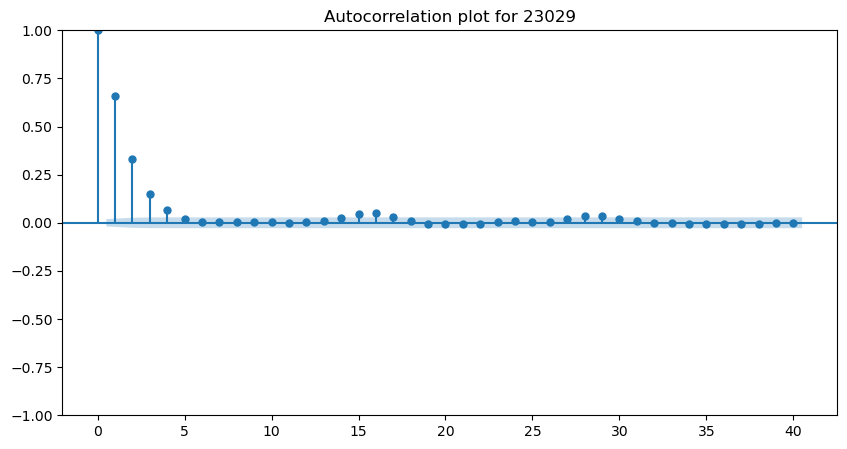

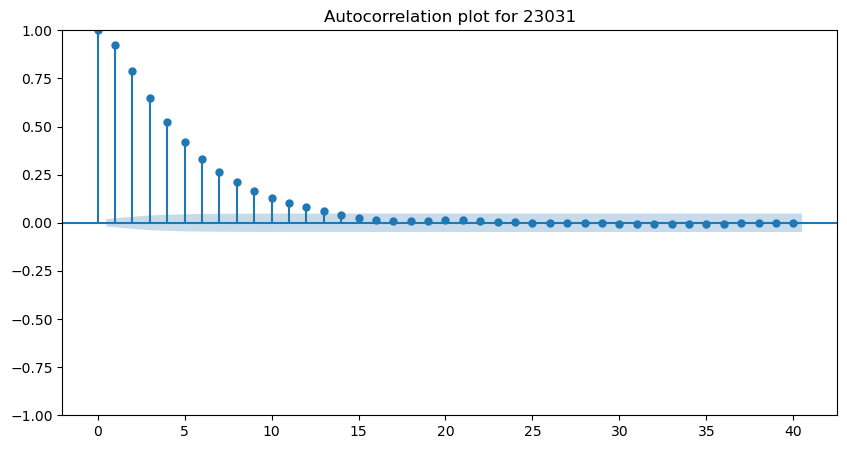

In [115]:
#For each value of fips_code use statsmodels to make an autocorrelation plot of y
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    sm.graphics.tsa.plot_acf(y_fips['customers_out'], lags=40, ax=ax)
    plt.title(f'Autocorrelation plot for {fips_code}')
    plt.show()

### Testing for stationarity

We'll use an augmented Dickey-Fuller test. All the p-values are quite tiny, suggesting stationarity.

This suggests that an autoregressive model is appropriate.

In [ ]:
# Create a numpy array to hold the fips_codes and p-values
p_values = np.zeros((16, 2))
i=0

#For each value of fips_code, run the Augmented Dickey-Fuller test
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    #sort y_fips
    y_fips = y_fips.sort_index()
    result = sm.tsa.stattools.adfuller(y_fips['customers_out'])
    p_values[i,0]=int(fips_code)
    p_values[i,1]=result[1]
    i=i+1
p_values

array([[2.30010000e+04, 2.04711212e-30],
       [2.30030000e+04, 0.00000000e+00],
       [2.30050000e+04, 1.41509829e-29],
       [2.30070000e+04, 0.00000000e+00],
       [2.30090000e+04, 0.00000000e+00],
       [2.30110000e+04, 6.02021067e-30],
       [2.30130000e+04, 0.00000000e+00],
       [2.30150000e+04, 3.10024335e-29],
       [2.30170000e+04, 0.00000000e+00],
       [2.30190000e+04, 0.00000000e+00],
       [2.30210000e+04, 0.00000000e+00],
       [2.30230000e+04, 1.70417674e-29],
       [2.30250000e+04, 5.65947724e-29],
       [2.30270000e+04, 1.43020080e-28],
       [2.30290000e+04, 0.00000000e+00],
       [2.30310000e+04, 0.00000000e+00]])

### PACF Plots

There is quite a bit of variation from county to county. The first and second lags are statistically significant for all counties. It isn't uncommon for the fourth and fith lags to also be statistically significant. 

This suggests we might use a fifth-order autoregressive model.

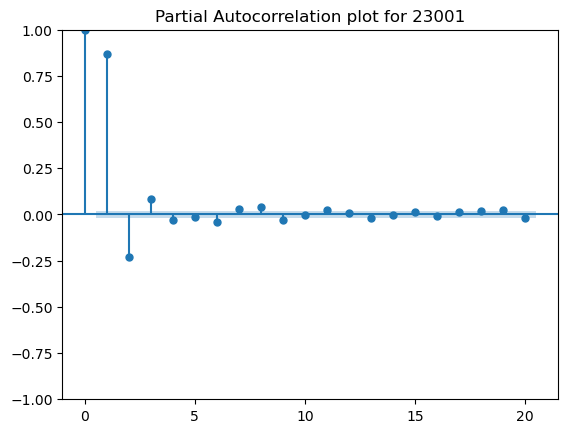

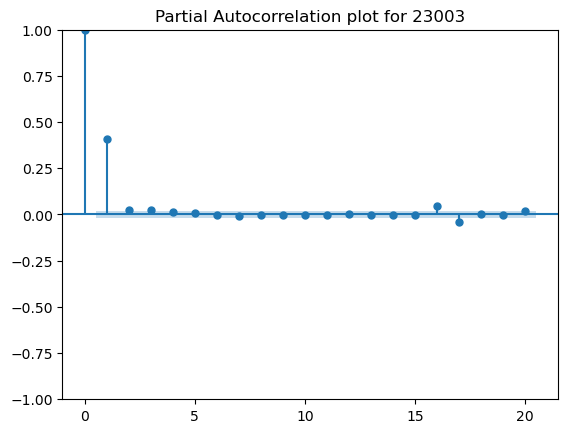

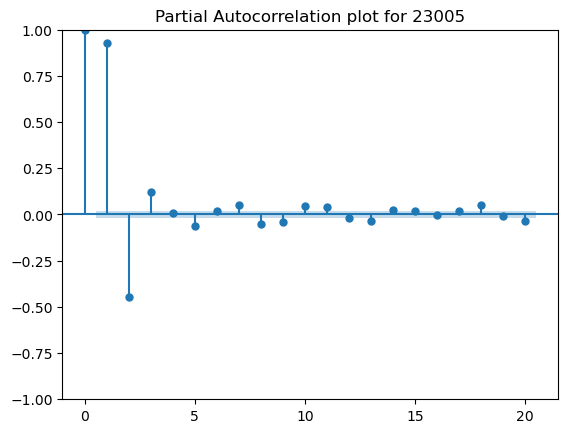

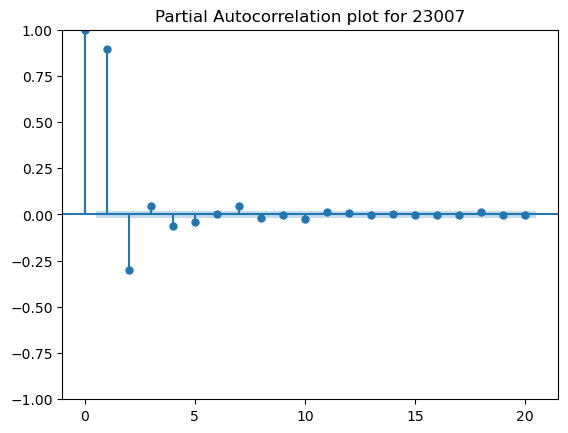

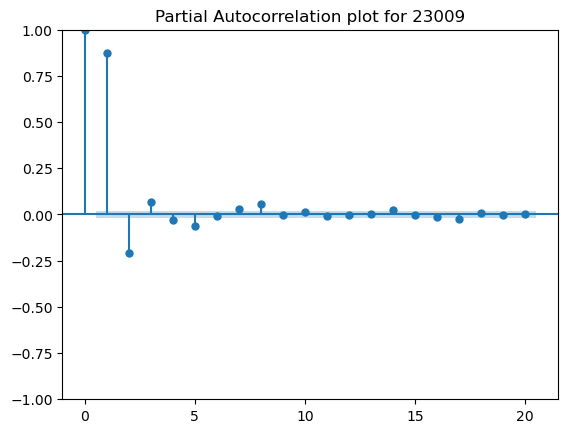

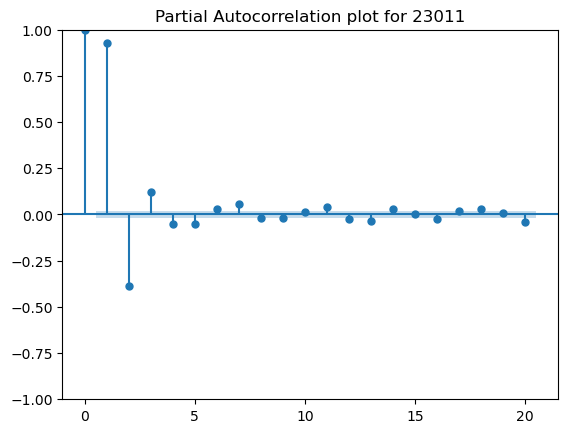

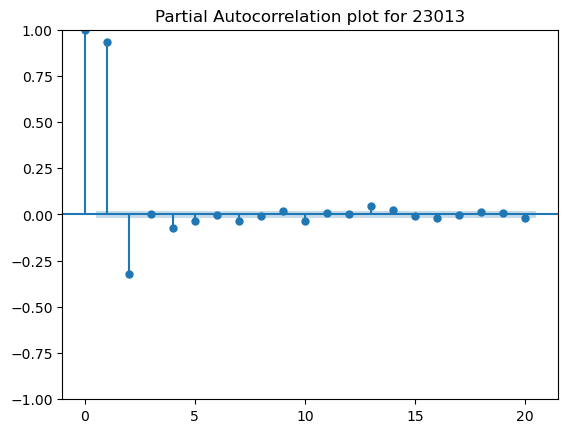

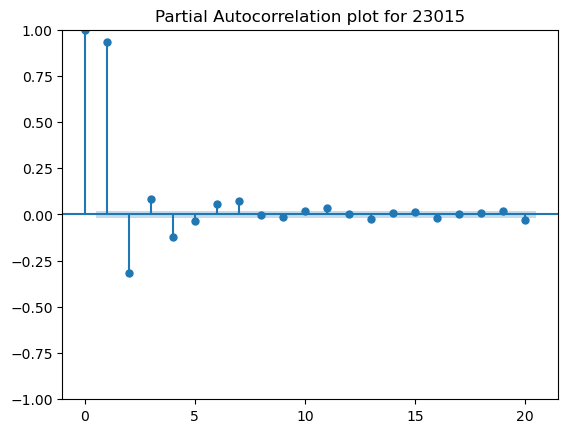

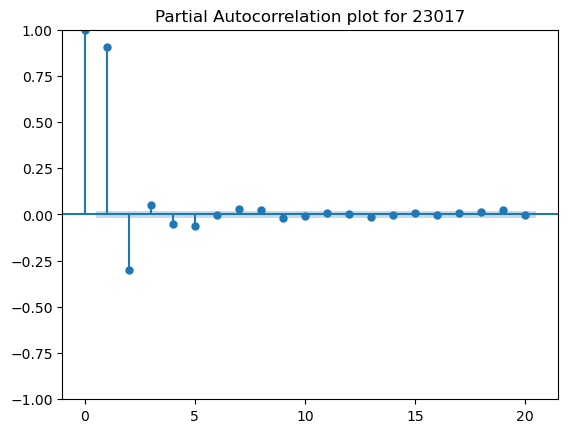

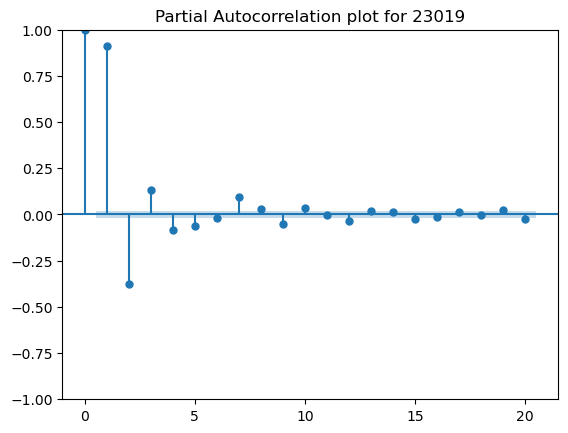

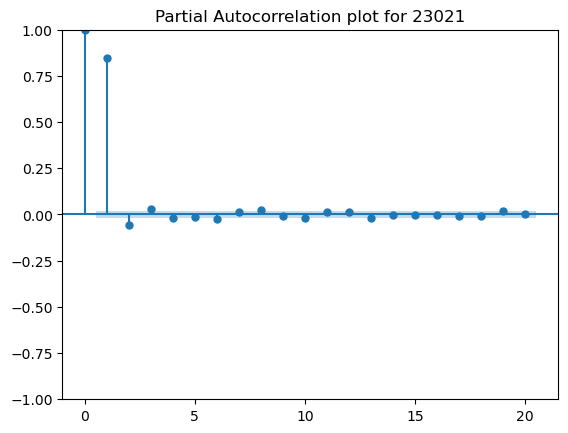

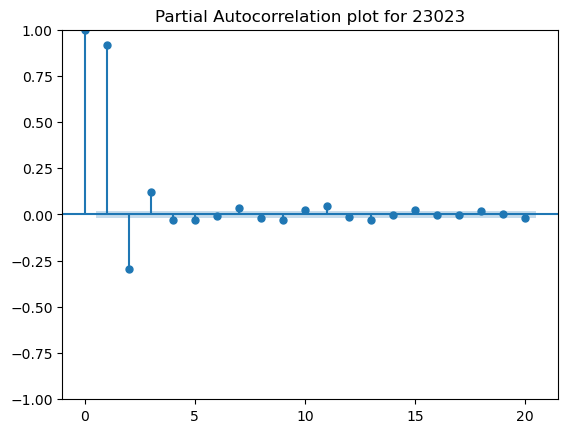

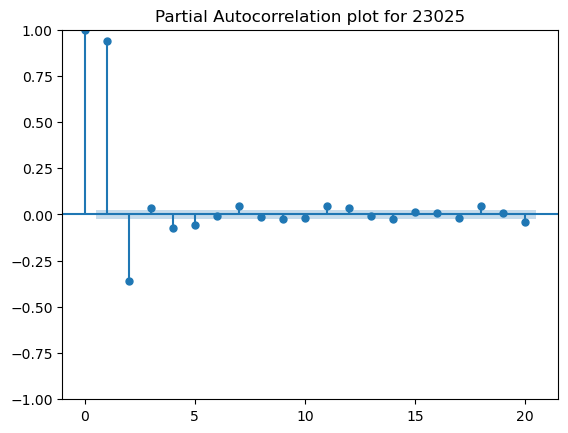

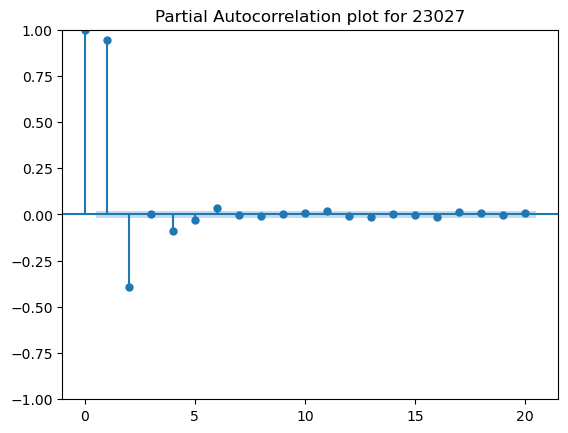

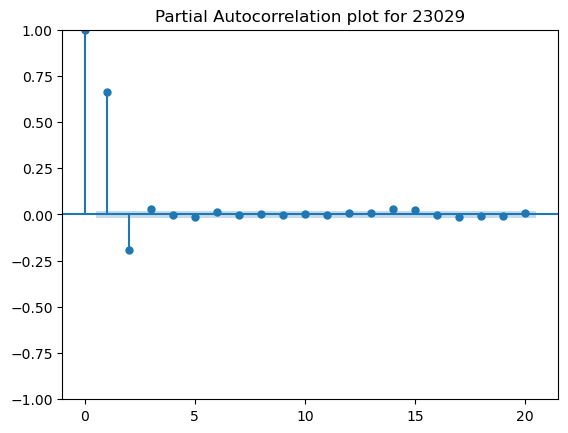

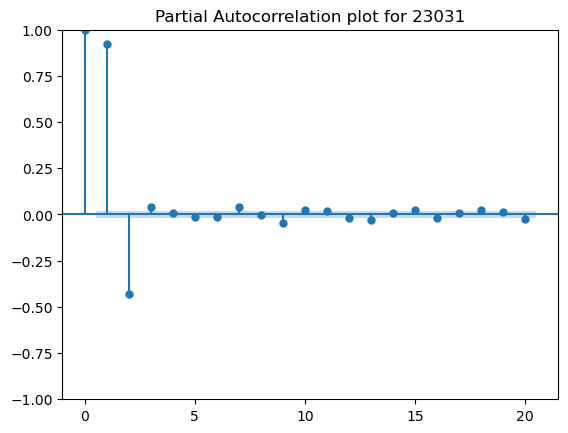

In [125]:
#For each value of fips_code make a partial autocorrelation plot of y
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    sm.graphics.tsa.plot_pacf(y_fips, lags=20, method='ols')
    plt.title(f'Partial Autocorrelation plot for {fips_code}')
    plt.show()

In [16]:
y_train_ll

Period
1947    60323.0
1948    61122.0
1949    60171.0
1950    61187.0
1951    63221.0
1952    63639.0
1953    64989.0
1954    63761.0
1955    66019.0
1956    67857.0
1957    68169.0
1958    66513.0
Freq: Y-DEC, Name: TOTEMP, dtype: float64

## SKTime Guides

Following guideas at:
- https://github.com/sktime/sktime/blob/main/examples/01_forecasting.ipynb
- https://www.sktime.net/en/latest/examples/01c_forecasting_hierarchical_global.html

## Trying ARMIA for Prediction

We'll make a train test split to check performance of a basic ARIMA model for predicting customers_out.

We'll use the last year as the test horizon, so 1460 total 6-hour time periods.

Then we'll make graphs to compare the predicted and actual values. 

The predictions were, predictably, terrible - it's only an order 5 model, so we wouldn't expect it to be accurate for much more than a day. 

In [ ]:
y_train, y_test = temporal_train_test_split(y, test_size=1460)

fh = ForecastingHorizon(y_test.index.get_level_values('datetime').unique(), is_relative=False)

forecaster = ARIMA(order=(5, 1, 0))
forecaster.fit(y_train)

y_pred = forecaster.predict(fh)

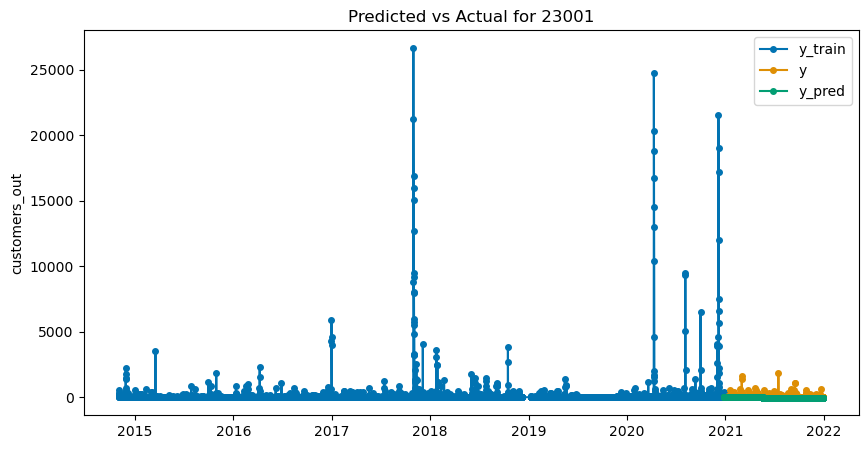

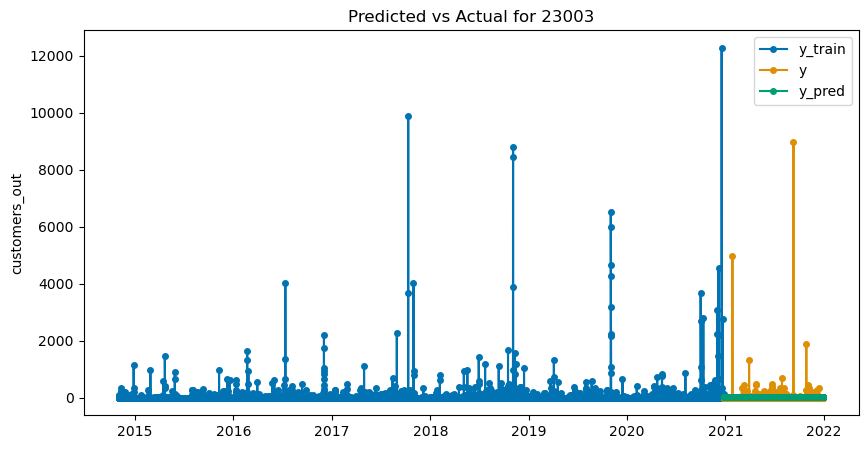

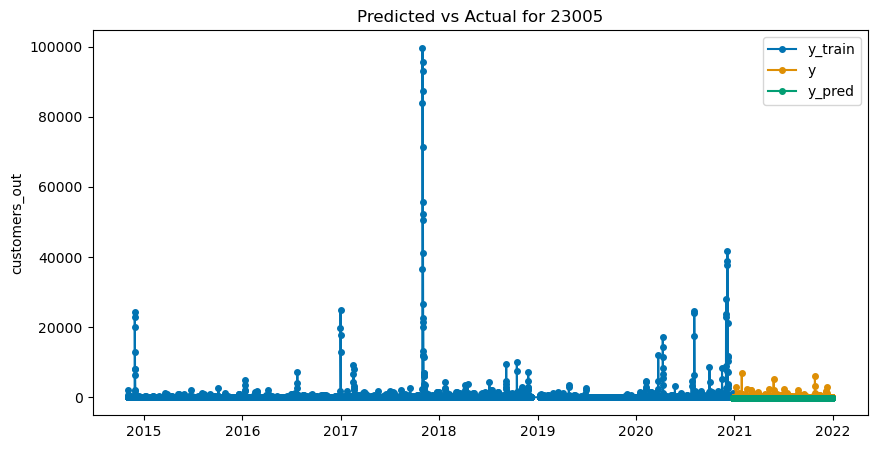

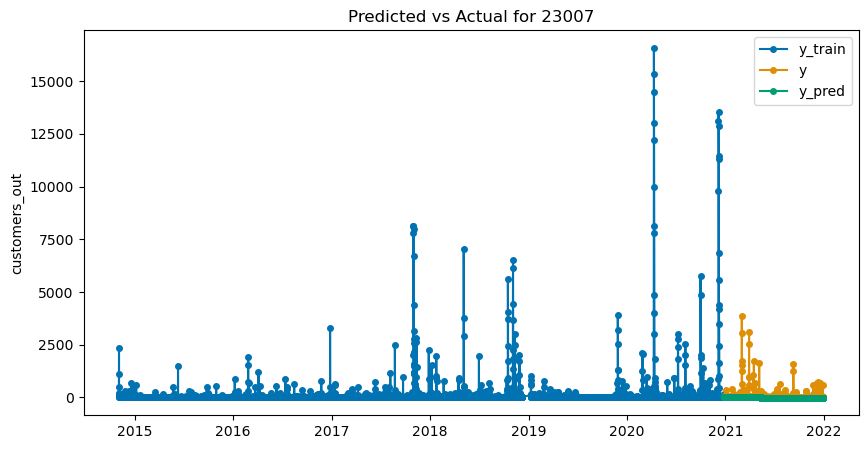

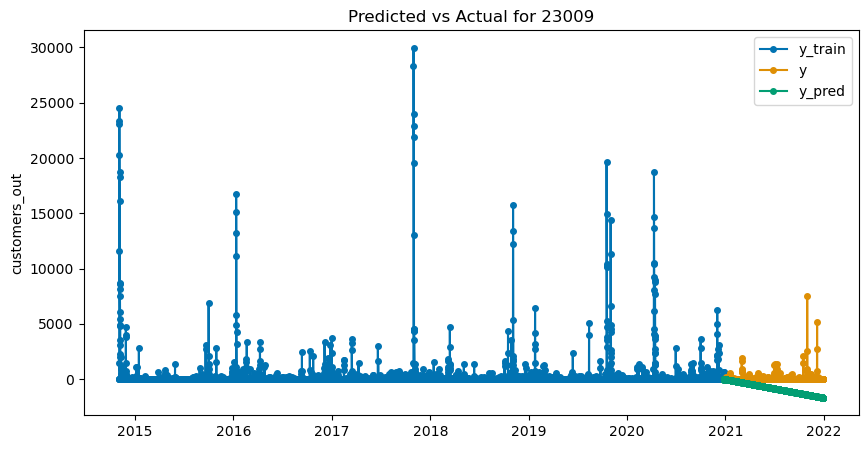

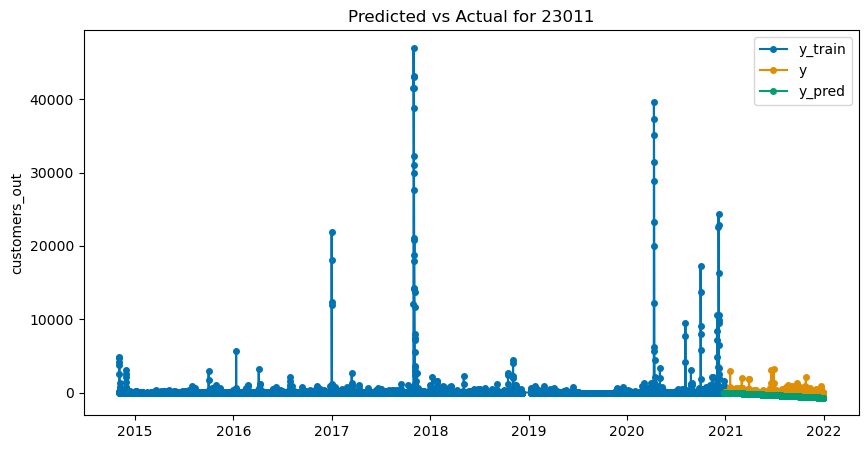

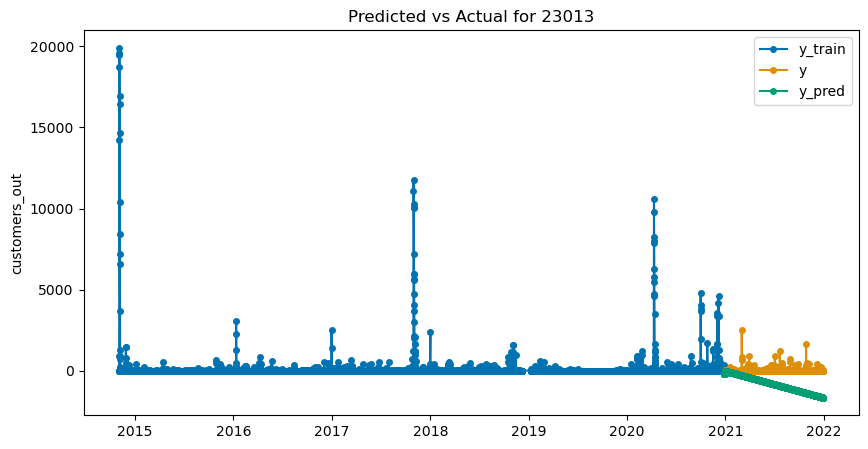

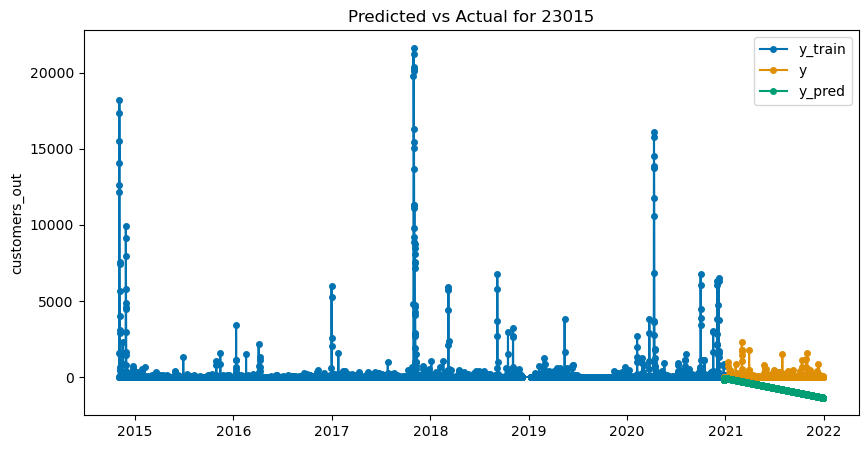

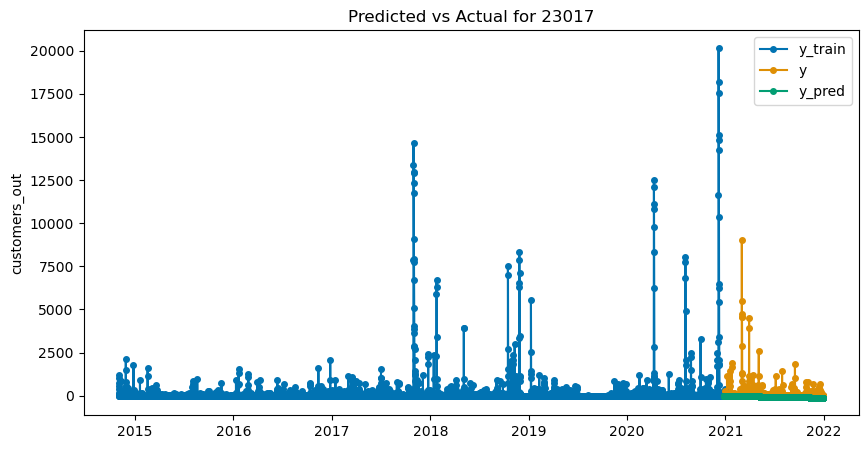

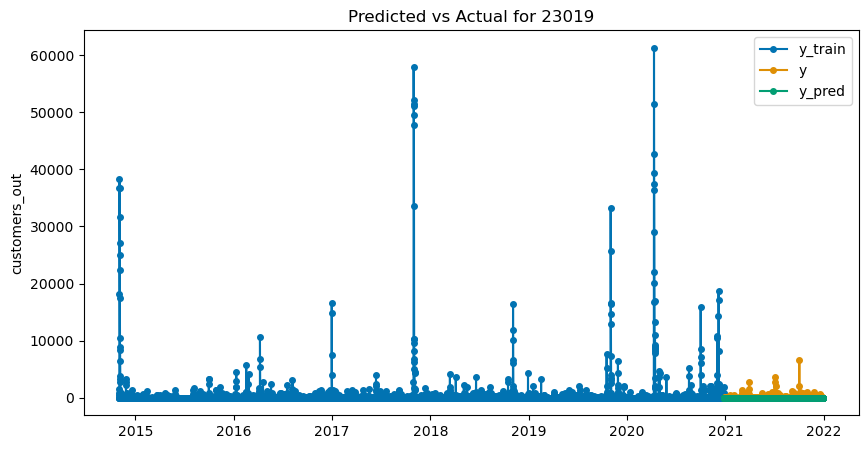

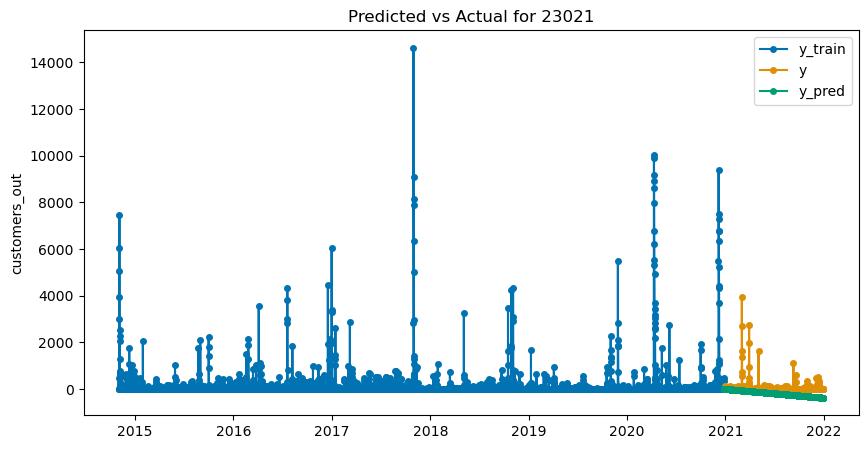

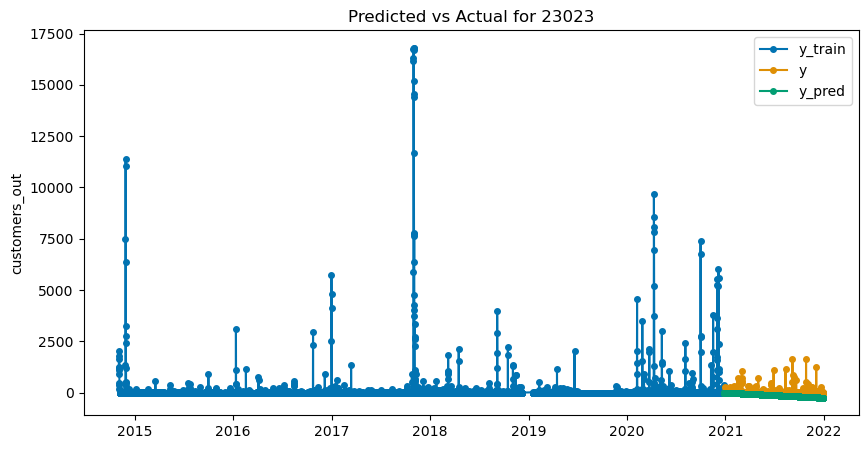

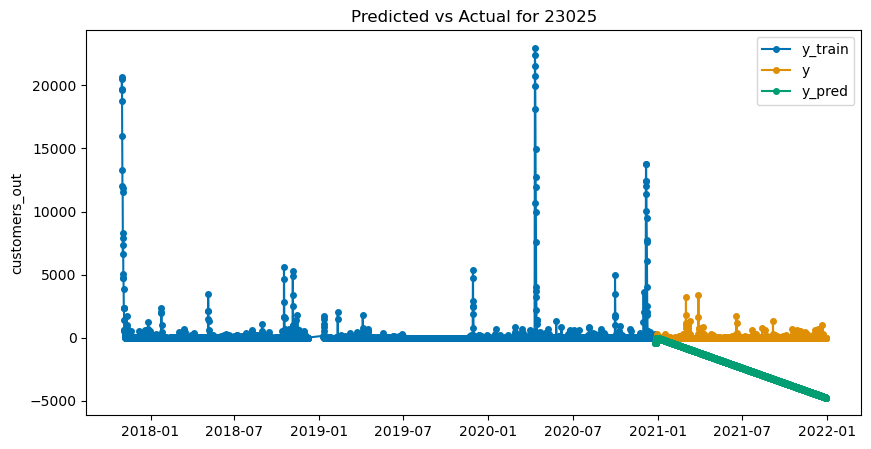

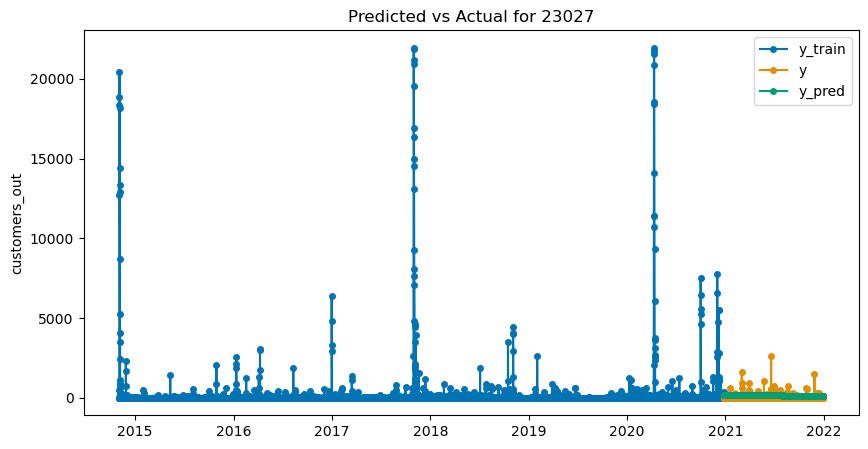

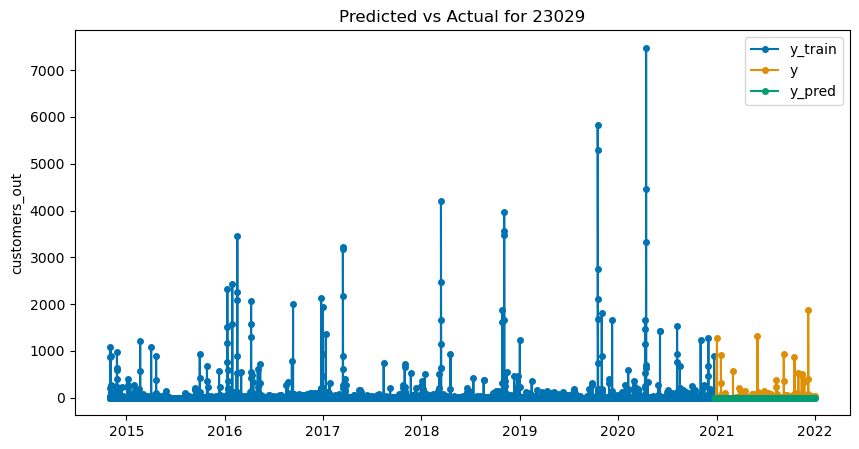

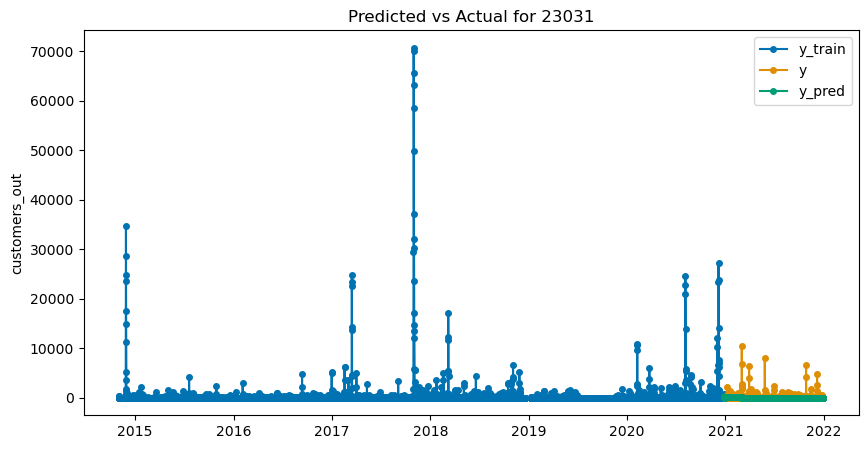

In [39]:
# Make plots for each fips_code to compare actual and predicted values on the test set
for fips_code in y.index.get_level_values(0).unique():
    y_train_fips = y_train.loc[fips_code]
    y_test_fips = y_test.loc[fips_code]
    y_pred_fips = y_pred.loc[fips_code]
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    plot_series(y_train_fips, y_test_fips, y_pred_fips, labels=["y_train", "y", "y_pred"], ax=ax)
    plt.title(f'Predicted vs Actual for {fips_code}')
    plt.show()

In [ ]:
#Evaluating the performance of the model

from sktime.performance_metrics.forecasting import mean_absolute_percentage_error
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError


# option 1: using the lean function interface
mean_absolute_percentage_error(y_test, y_pred, symmetric=False)
# note: the FIRST argument is the ground truth, the SECOND argument are the forecasts
#       the order matters for most metrics in general

# option 2: using the composable class interface
mape = MeanAbsolutePercentageError(symmetric=False)
# the class interface allows to easily construct variants of the MAPE
#  e.g., the non-symmetric version
# it also allows for inspection of metric properties
#  e.g., are higher values better (answer: no)?
mape.get_tag("lower_is_better")

# evaluation works exactly like in option 2, but with the instantiated object
mape(y_test, y_pred)

### Trying ARIMA for Prediction with a Sliding Window